#Understanding the Data

##Patient and Demographic Info
1. ***`dep_name`*** – Name of the ED/department (useful if the data spans multiple hospital sites)
2. ***`esi`*** – Emergency Severity Index: a 1–5 triage urgency score assigned
at intake. 1 = most critical (resuscitation needed), 5 = least urgent (minor complaint). This is the standard triage acuity scale used in most U.S./North American EDs.
3. ***`age`***, ***`gender`*** – Age, gender
4. ***`ethnicity`***, ***`race`*** – Self-reported demographic categories (often separate columns because "ethnicity" and "race" are tracked as distinct fields in US health records, e.g., Hispanic/Non-Hispanic as ethnicity, separate from race categories)
5. ***`lang`*** – Patient's preferred/primary language
6. ***`religion`*** – Self-reported religious affiliation
7. ***`maritalstatus`*** – Married/single/divorced/etc.
8. ***`employstatus`*** – Employment status
9. ***`insurance_status`*** – Type of coverage (private, Medicaid, uninsured, etc.) — often a proxy for socioeconomic status in health equity research

##Visit and Arrival Info
1. ***`disposition`*** – What happened to the patient at the end of the ED visit: discharged home, admitted to hospital, transferred, left without being seen, etc. This is often the outcome variable for triage/prediction models.
2. ***`arrivalmode`*** – How the patient got to the ED: walk-in, ambulance, police, private vehicle, etc.
3. ***`arrivalmonth`***, ***`arrivalday`***, ***`arrivalhour_bin`*** – When they arrived (hour is "binned," meaning grouped into ranges like 0–4, 4–8, etc., rather than exact minute)
4. ***`previousdispo`*** – Disposition from a prior/previous ED visit (useful for tracking returning patients — a "bounce-back" indicator)

##Triage Vitals
1. ***`triage_vital_hr`*** – Heart rate (beats per minute)
2. ***`triage_vital_sbp`*** / dbp – Systolic / diastolic blood pressure (the "top" and "bottom" numbers)
3. ***`triage_vital_rr`*** – Respiratory rate (breaths per minute)
4. `***triage_vital_o2***` – Oxygen saturation (%), i.e., how well oxygenated the blood is
5. ***`triage_vital_o2_device`*** – Whether the O2 reading was on room air or with support (e.g., nasal cannula, mask)
6. ***`triage_vital_temp`*** `Inline code` – Body temperature
7. ***`triage_glucose`*** – Blood sugar level at triage (not always measured — only relevant for certain complaints like diabetes-related visits)

##Chief Complaint Flags
These flags are either yes(1) or no (0). They represent the chief complaint for a specific patient reported at triage. A single patient can have multiple flags.

#Top 10 Features That Indicate Triage Level

The following features are the indicators that are most predictive of triage level in no particular order:


1. Oxygen Saturation (***`triage_vital_o2`***)
2. Chief Complaint (each cc block)
3. Systolic Blood Pressure (***`triage_vital_sbp`***)
4. Heart Rate (***`triage_vital_hr`***)
5. Respiratory Rate (***`triage_vital_rr`***)
6. Temperature (***`triage_vital_temp`***)
7. Mode of Arrival (***`arrivalmode`***)
8. Age (***`age`***)
9. History (***`previousdispo`***)
10. Pain Complaints (cc blocks related to pain)

#Feasibility Study

Link to Feasibility Study: https://drive.google.com/file/d/1qjc1eK5k0L3CSorM8EHhw1OOX-mpLQ2G/view?usp=sharing

#Initial Environment Setup
The code below shows the Google Colab environment being setup by mounting the files, importing the required libraries, and loading the CSV file (our dataframe).

In [1]:
#Mounting Google Drive files
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print ("Libraries imported successfully!")

#Loading the CSV
FILEPATH = "/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv"
df = pd.read_csv(FILEPATH)
print(f"Dataset Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Mounted at /content/drive
Drive mounted successfully!


#Initial Data Exploration
The data is initially explored to see what exactly is being worked with. Firstly, the head of the data is obtained to see the distribution of columns and rows. While this is an inefficient way to explore this current dataset, due to the vast number of rows and columns, its still good to see the head of your data to know how to proceed with exploring the rest of it.

Afterwhich, the info of the data was gathered to note the total range, number of column entries and the data types used.

When working with large data it is very important to note if there are any weird values within the frame. As such, the data was explored to see if any of the data types returned NaN. As the result showed, there were none. So all the data types were good to work with.

Next, the data was grouped a bit. The chief complaints were plenty in number, and very scattered. It was important that each cc was put under a category for the data to be worked on better. As such, each cc was grouped under categories such as Traume, Neurological, Respiratory, etc.

In [17]:
#Looking at the first few rows
print(df.head(10))

   Unnamed: 0 dep_name  esi   age  gender           ethnicity  \
0           7        A  4.0  87.0  Female  Hispanic or Latino   
1          17        B  2.0  53.0    Male  Hispanic or Latino   
2          40        A  2.0  49.0  Female        Non-Hispanic   
3          47        A  3.0  22.0  Female  Hispanic or Latino   
4          60        A  2.0  62.0    Male        Non-Hispanic   
5          61        A  2.0  62.0    Male        Non-Hispanic   
6          86        B  4.0  38.0  Female  Hispanic or Latino   
7          87        A  3.0  39.0  Female  Hispanic or Latino   
8          88        B  3.0  39.0  Female  Hispanic or Latino   
9          95        C  3.0  26.0  Female        Non-Hispanic   

                 race     lang     religion      maritalstatus  ...  \
0               Other    Other  Pentecostal            Widowed  ...   
1               Other  English     Catholic  Significant Other  ...   
2  White or Caucasian  English     Catholic            Married  ...   


In [5]:
#Looking at the info of the data frame
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Columns: 226 entries, Unnamed: 0 to cc_wristpain
dtypes: float64(210), int64(1), object(15)
memory usage: 95.0+ MB
None


In [6]:
#Looking if there are any missing values
columns = df.columns.tolist()
print(f"NaN count:\n{df[columns].isnull().sum()}")

NaN count:
Unnamed: 0               0
dep_name                 0
esi                      0
age                      0
gender                   0
                        ..
cc_woundcheck            0
cc_woundinfection        0
cc_woundre-evaluation    0
cc_wristinjury           0
cc_wristpain             0
Length: 226, dtype: int64


In [8]:
cc_flags = [c for c in df.columns if c.startswith("cc_")]

# Ordered (category -> keywords) rules. FIRST MATCH WINS, so specific systems come
# before the Trauma/MSK "pain/injury/swelling" near-catch-all, and Other is last.
CC_CATEGORIES = [
    ("Cardiovascular",             ["chestpain","chesttightness","palpitation","irregularheart","rapidheart","tachycard","hypertens","hypotens","cardiacarrest"]),
    ("Genitourinary/Renal",        ["dysuria","hematuria","urinary","flank","testicle","maleguproblem","femaleguproblem","groin","pelvic","vaginal","breastpain","std"]),
    ("Respiratory",                ["breathing","shortnessofbreath","dyspnea","cough","wheez","respiratory","asthma","hemoptysis","coldlike","nasalcongest","influenza","sinus","sorethroat","uri"]),
    ("Neurological",               ["headache","migraine","dizz","syncope","seizure","stroke","alteredmental","confusion","numbness","lossofconsciousness","unresponsive","lethargy","neurologic","hallucinat","extremityweakness"]),
    ("Gastrointestinal",           ["abdominal","epigastric","nausea","emesis","vomit","diarrhea","constipation","gibleeding","giproblem","rectal","swallowedforeign","ingestion","dehydration"]),
    ("Psych/Behavioral/Substance", ["anxiety","depress","agitation","suicid","homicid","psychot","psychiatric","panic","alcohol","drugproblem","drug/alcohol","addiction","detox","overdose","withdrawal","poison"]),
    ("ENT/Eye/Dental",             ["earpain","earproblem","otalgia","eye","conjunctiv","foreignbodyineye","blurredvision","dental","jaw","epistaxis","facial","oralswelling"]),
    ("Skin/Soft-tissue",           ["rash","cellulitis","abscess","cyst","skin","wound","mass","allergicreaction","edema","bruising"]),
    ("Endocrine/Metabolic/Heme",   ["bloodsugar","glycem","glucose","sicklecell"]),
    ("Constitutional/General",     ["fever","chills","fatigue","bodyache","generalizedbody","weakness"]),
    ("Trauma/Injury/MSK",          ["injury","fall","trauma","laceration","fracture","back","neck","joint","rib","assault","burn","animalbite","insectbite","pain","swelling"]),
]

def categorize(flag):
    stem = flag[3:]                     # drop the "cc_" prefix
    if "crash" in stem:                 # 'crash' contains 'rash' -> disambiguate FIRST
        return "Trauma/Injury/MSK"
    for category, keywords in CC_CATEGORIES:
        if any(k in stem for k in keywords):
            return category
    return "Other/Procedural/Admin"

# Build category -> list of flags, and confirm we placed every one.
from collections import defaultdict
groups = defaultdict(list)
for flag in cc_flags:
    groups[categorize(flag)].append(flag)

order = [name for name, _ in CC_CATEGORIES] + ["Other/Procedural/Admin"]
for name in order:
    print(f"{name:28s} {len(groups[name]):3d} flags")
print("-" * 40)
print(f"{'TOTAL placed':28s} {sum(len(v) for v in groups.values()):3d} of {len(cc_flags)}")




Cardiovascular                 9 flags
Genitourinary/Renal           17 flags
Respiratory                   15 flags
Neurological                  21 flags
Gastrointestinal              16 flags
Psych/Behavioral/Substance    18 flags
ENT/Eye/Dental                18 flags
Skin/Soft-tissue              14 flags
Endocrine/Metabolic/Heme       5 flags
Constitutional/General         8 flags
Trauma/Injury/MSK             49 flags
Other/Procedural/Admin        10 flags
----------------------------------------
TOTAL placed                 200 of 200


#P1 - Missingness Table
Initially the chief complaint columns are put together neatly and assigned to the variable called "*`structured`*". Those chief complaints, per cell in each column, are evaluated using `.isna()`, to see if there are any missing values. Missing values = *`True`* | Present values = *`False`*. Afterwhich, the mean is taken from all those *`True`*/*`False`* collections and assinged to the variable "*`missing_fraction`*".

The variable "*`missing_fraction`*" is then turned into a percentage; multipying the variable by 100, rounded by 1 decimal place and then sorted by the highest percentage of False first. When that is done, that value is assigned to "*`missing_percent`*". The values assigned to the variable are then filtered to remove all the values that are less than 0.

Therefore, the data that was previously computed and cleaned, was visualized in a graph format to see. The graph shows present data as grey bars, while missing data is shown as white space. As seen in the graph, there are no white spaces. Meaning that the data from the cc columns are all present.


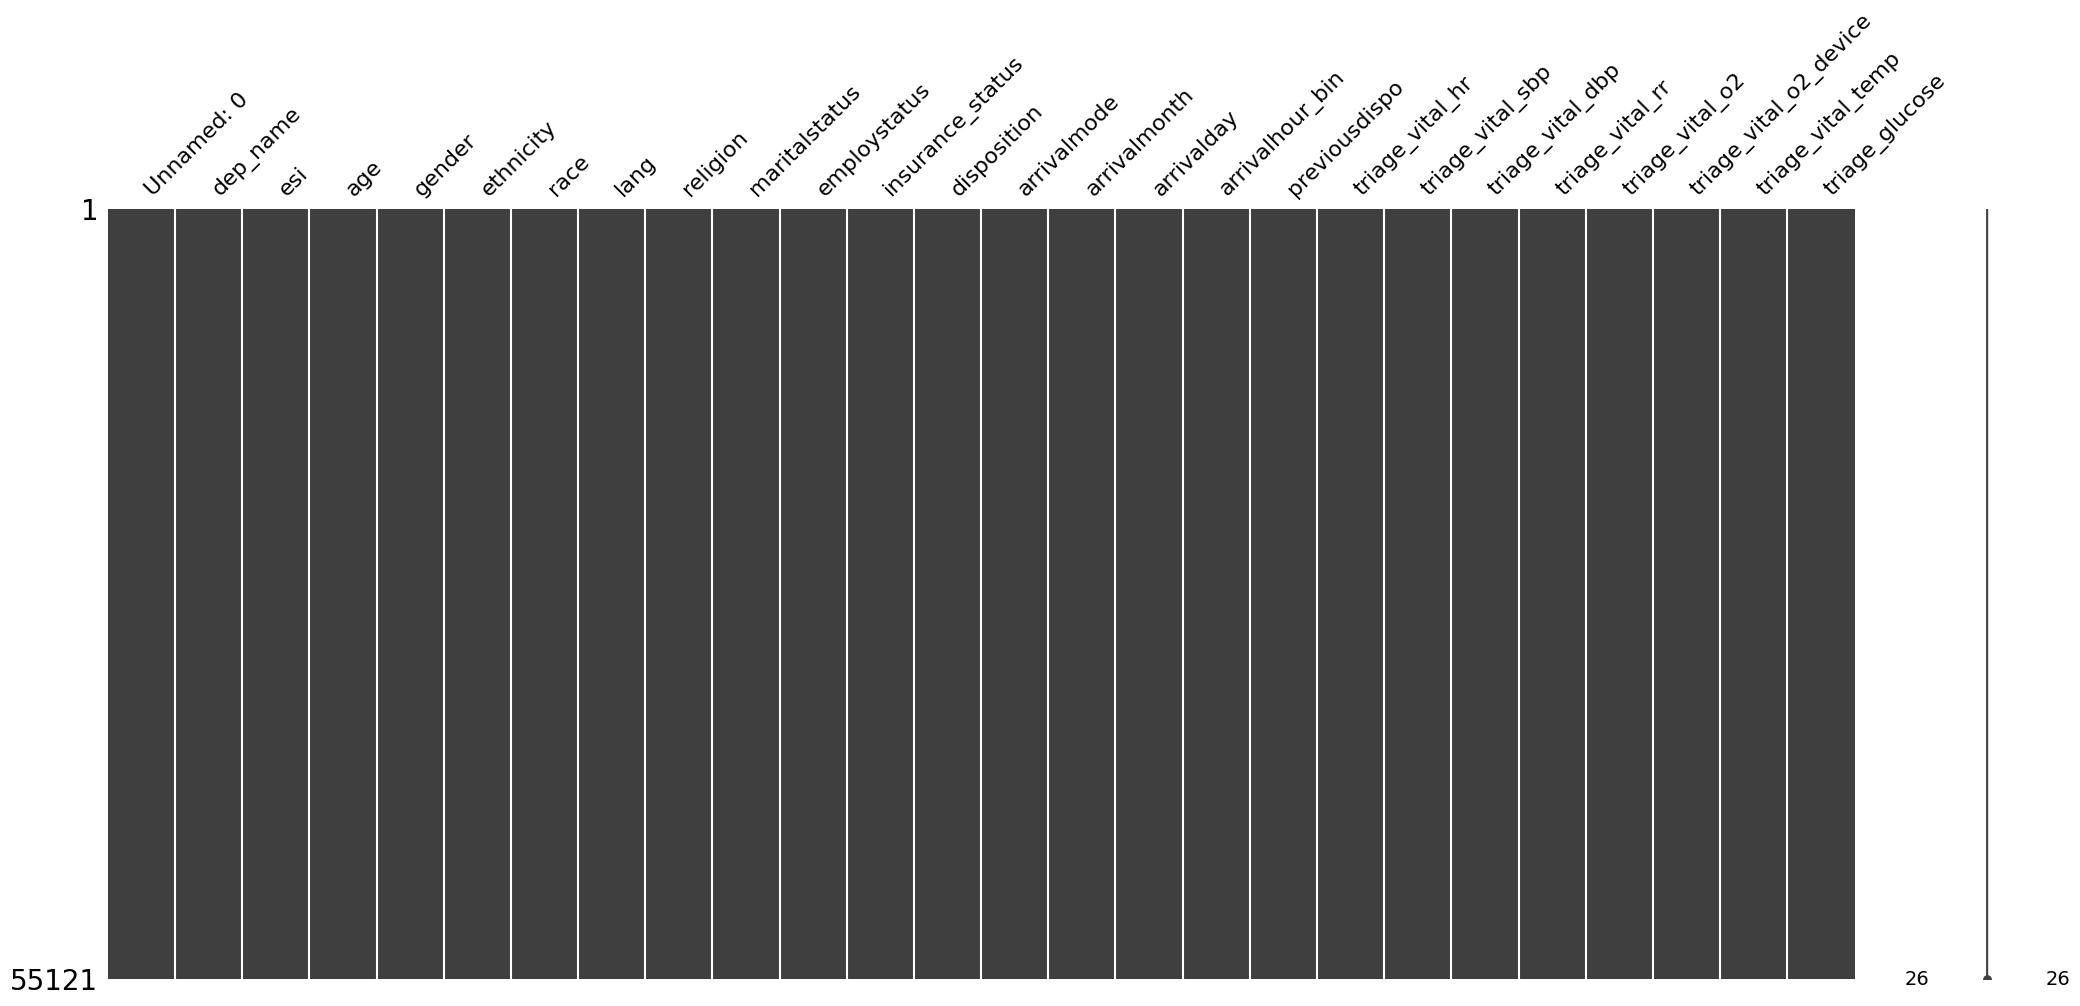

In [13]:

structured = [col for col in df.columns if not col.startswith("cc_")]

missing_fraction = df[structured].isna().mean()
missing_percent = (missing_fraction * 100).round(1)
missing_percent = missing_percent.sort_values(ascending=False)
missing_percent[missing_percent > 0]

try:
    import missingno as msno
    msno.matrix(df[structured]); plt.show()
except Exception:
    fig, ax = plt.subplots(figsize=(11,4))
    ax.imshow(df[structured].isna().values, aspect="auto", cmap="gray_r")
    ax.set_xticks(range(len(structured))); ax.set_xticklabels(structured, rotation=90, fontsize=7)
    ax.set_title("Missing cells — structured columns"); plt.tight_layout(); plt.show()

#Distributions

The code below shows the distributions of each vital sign used in triage. To get the graphs the data is grouped by name and assigned to its respective variable, which also denotes its category. For example, *`VITALS`* covers heart rate, temperature, blood glucose, etc. Afterwhich, the data is grouped into a dictionary, with the groups acting as keys.

For the graphs below, since we want to showcase the vital signs and their distributions, we utilized the *`VITALS`* dictionary and made plots from that data.

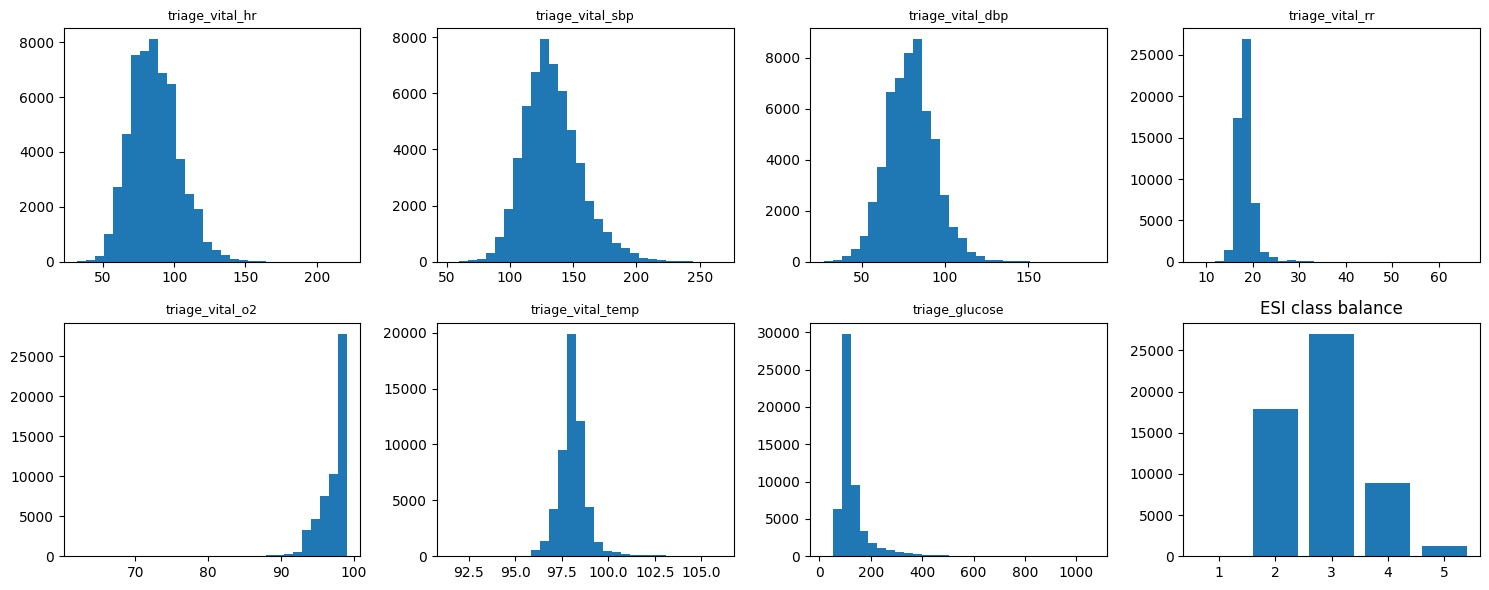

In [20]:
TARGET = "esi"

VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

LEAKAGE = ["disposition", "previousdispo"]

NORMAL_RANGES = {"triage_vital_hr": (60,100,"bpm"), "triage_vital_sbp": (90,140,"mmHg"),
    "triage_vital_dbp": (60,90,"mmHg"), "triage_vital_rr": (12,20,"/min"),
    "triage_vital_o2": (95,100,"%"), "triage_vital_temp": (97.0,99.5,"F"), "triage_glucose": (70,140,"mg/dL")}

PLAUSIBLE = {"age": (0,120), "esi": (1,5), "triage_vital_hr": (20,250), "triage_vital_sbp": (50,300),
    "triage_vital_dbp": (20,200), "triage_vital_rr": (4,60), "triage_vital_o2": (50,100),
    "triage_vital_temp": (86,110), "triage_glucose": (20,800)}


def classify_columns(df):

    def keep_present(wanted):
        present = []
        for col in wanted:
            if col in df.columns:
                present.append(col)
        return present

    chief_complaints = []
    for col in df.columns:
        if col.startswith("cc_"):
            chief_complaints.append(col)

    families = {
        "target":           keep_present([TARGET]),
        "vitals":           keep_present(VITALS),
        "demographics":     keep_present(DEMOGRAPHICS),
        "admin":            keep_present(ADMIN),
        "leakage":          keep_present(LEAKAGE),
        "chief_complaints": chief_complaints,
    }
    return families

fam = classify_columns(df)

vitals = fam["vitals"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
panels = axes.ravel()

for panel, col in zip(panels, vitals):
    values = pd.to_numeric(df[col], errors="coerce").dropna()
    panel.hist(values, bins=30)
    panel.set_title(col, fontsize=9)
    pass

esi_counts = df[TARGET].value_counts().sort_index()
panels[-1].bar(esi_counts.index, esi_counts.values)
panels[-1].set_title("ESI class balance")

plt.tight_layout(); plt.show()

In [22]:
import os
def clean_triage(raw):
    """Canonical Week-5 cleaning pipeline (the same steps you build in Tutorial 3).
    Takes the raw DataFrame and returns a cleaned copy."""
    d = raw.copy()
    fam = classify_columns(d)

    d = d[d[TARGET].notna()].copy()

    numeric_cols = list(fam["vitals"])
    if "age" in d.columns:
        numeric_cols.append("age")
    for col in numeric_cols:
        d[col] = pd.to_numeric(d[col], errors="coerce")

    for col in PLAUSIBLE:
        low, high = PLAUSIBLE[col]
        if col in d.columns:
            out_of_range = (d[col] < low) | (d[col] > high)
            d.loc[out_of_range, col] = np.nan

    for col in fam["vitals"]:
        d[col] = d[col].fillna(d[col].median())

    if "triage_vital_o2_device" in d.columns:
        d["triage_vital_o2_device"] = d["triage_vital_o2_device"].fillna(0)
    for col in fam["chief_complaints"]:
        d[col] = d[col].fillna(0)

    for col in fam["demographics"] + fam["admin"] + fam["leakage"]:
        if d[col].dtype == object:
            d[col] = d[col].fillna("Unknown")

    d[TARGET] = d[TARGET].round().astype(int)
    return d

#P2 - ESI Class Balance and Age Distribution

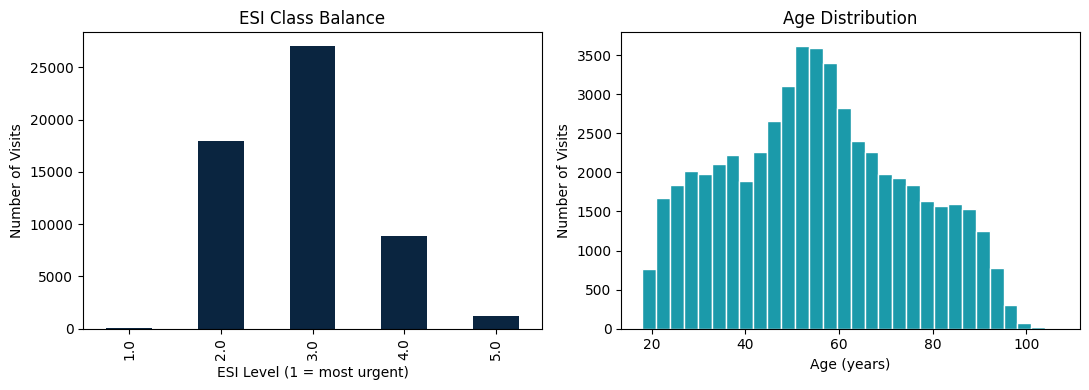

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

esi_counts = df[TARGET].value_counts().sort_index()
esi_counts.plot.bar(ax=ax[0], color="#0A2540")
ax[0].set_title("ESI Class Balance")
ax[0].set_xlabel("ESI Level (1 = most urgent)")
ax[0].set_ylabel("Number of Visits")

ax[1].hist(df["age"], bins=30, color="#1B9AAA", edgecolor="white")
ax[1].set_title("Age Distribution")
ax[1].set_xlabel("Age (years)")
ax[1].set_ylabel("Number of Visits")

plt.tight_layout(); plt.show()

#P3 - Race and Ethnicity Distribution

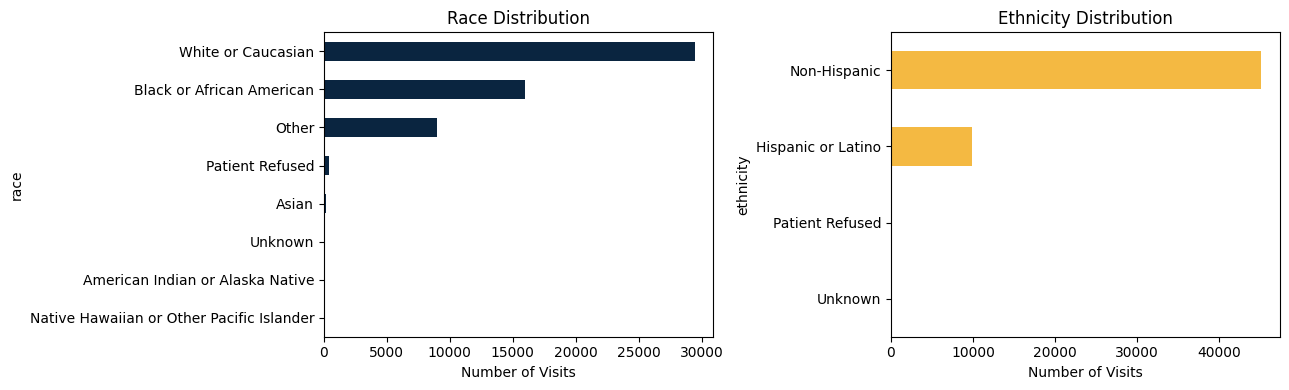

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))

df["race"].value_counts().plot.barh(ax=ax[0], color="#0A2540")
ax[0].set_title("Race Distribution")
ax[0].set_xlabel("Number of Visits")
ax[0].invert_yaxis()

df["ethnicity"].value_counts().plot.barh(ax=ax[1], color="#F4B942")
ax[1].set_title("Ethnicity Distribution")
ax[1].set_xlabel("Number of Visits")
ax[1].invert_yaxis()

plt.tight_layout(); plt.show()

#P4 - Top Chief Complaints

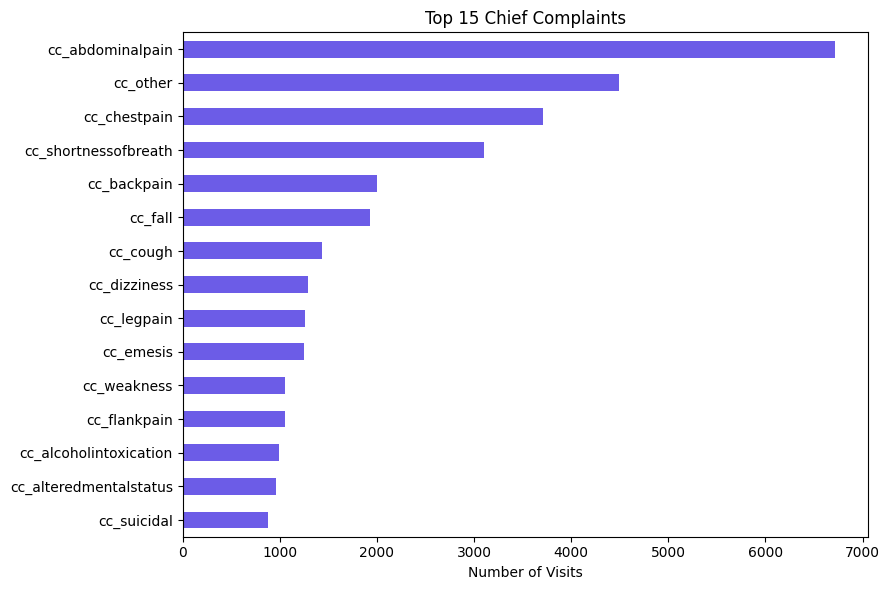

In [28]:
complaint_counts = df[fam["chief_complaints"]].sum()
top15 = complaint_counts.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9,6))
top15[::-1].plot.barh(ax=ax, color="#6C5CE7")
ax.set_title("Top 15 Chief Complaints")
ax.set_xlabel("Number of Visits")

plt.tight_layout(); plt.show()

#P5 - Do Vitals Separate the ESI Classes?

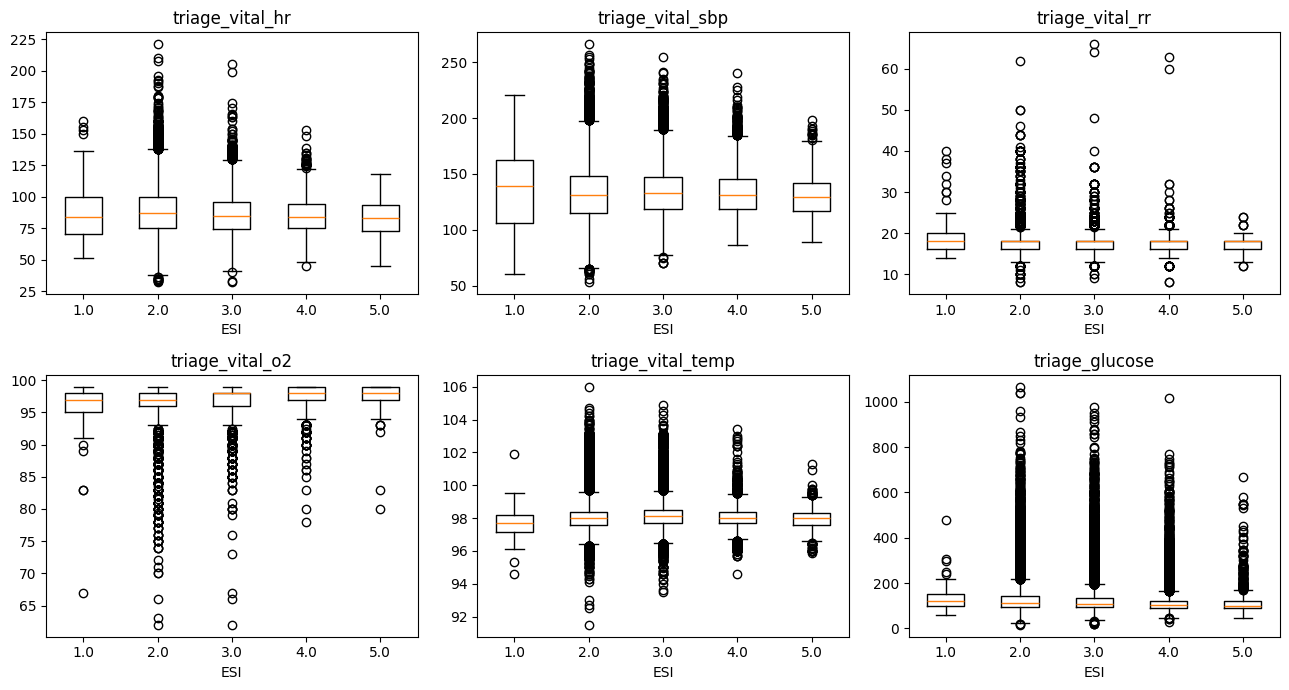

In [30]:
vitals_to_plot = ["triage_vital_hr","triage_vital_sbp","triage_vital_rr",
                  "triage_vital_o2","triage_vital_temp","triage_glucose"]
esi_levels = sorted(df[TARGET].unique())
fig, axes = plt.subplots(2, 3, figsize=(13,7))
for panel, col in zip(axes.ravel(), vitals_to_plot):
    groups = [df.loc[df[TARGET] == level, col] for level in esi_levels]
    panel.boxplot(groups, tick_labels=esi_levels)
    panel.set_title(col)
    panel.set_xlabel("ESI")
plt.tight_layout(); plt.show()

#P6 - Vitals vs ESI Correlation Heatmap

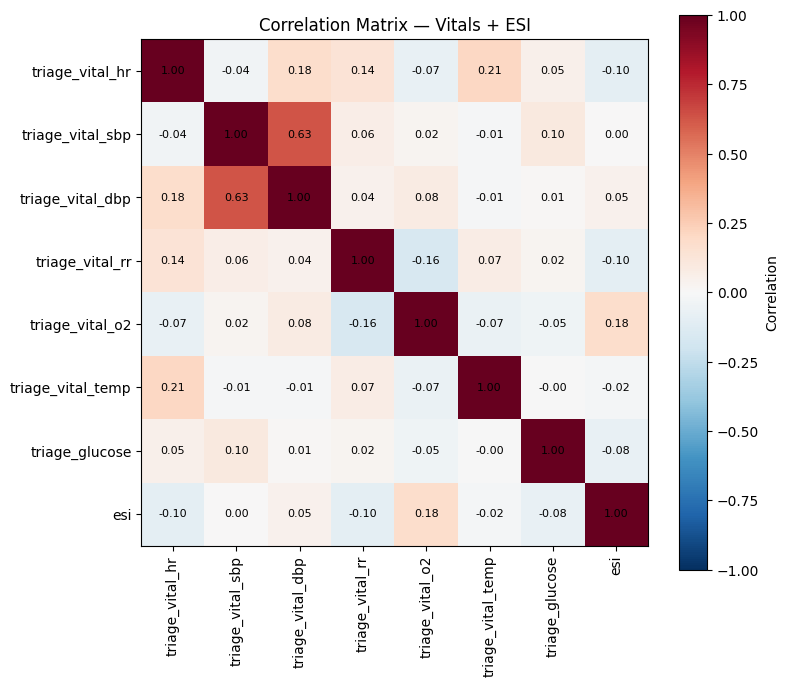

In [32]:
cols = fam["vitals"] + [TARGET]
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlation")
ax.set_title("Correlation Matrix — Vitals + ESI")

plt.tight_layout(); plt.show()